### Problem 1
Implement serial test and apply to a `samples`

In [46]:
# Your code here
import numpy as np
from scipy.stats import chisquare

def serial_test(samples, dim=2, bins_per_dim=10):

    samples = np.asarray(samples, dtype=float).ravel()

    n = len(samples)
    if n % dim != 0:
        samples = samples[:n - (n % dim)]

    num_tuples = len(samples) // dim

    tuples = samples.reshape(num_tuples, dim)

    tuples = np.clip(tuples, 0.0, 0.999999)

    bin_indices = np.floor(tuples * bins_per_dim).astype(int)

    flat_bins = np.zeros(num_tuples, dtype=int)
    multiplier = 1
    for d in range(dim):
        flat_bins += bin_indices[:, d] * multiplier
        multiplier *= bins_per_dim

    observed = np.bincount(flat_bins, minlength=bins_per_dim**dim)

    expected = np.full(bins_per_dim**dim, num_tuples / (bins_per_dim**dim))

    chi2_stat, p_value = chisquare(observed, expected)

    return chi2_stat, p_value

samples = np.random.rand(10000)
if 'samples' in globals():
    chi2, p = serial_test(samples, dim=2, bins_per_dim=10)
    print(f"Serial test (dim=2, 10×10 bins)")
    print(f"Chi-square statistic : {chi2:.4f}")
    print(f"p-value              : {p:.6f}")

    alpha = 0.05
    if p > alpha:
        print("Sequence passes the serial test at 5% significance level.")
    else:
        print("Sequence fails the serial test at 5% significance level.")
else:
    print("Variable `samples` not found. Define it first (e.g. samples = np.random.rand(10000)).")




Serial test (dim=2, 10×10 bins)
Chi-square statistic : 102.6400
p-value              : 0.381007
Sequence passes the serial test at 5% significance level.


### Problem 2*
Implement permutation test and apply to a `samples`

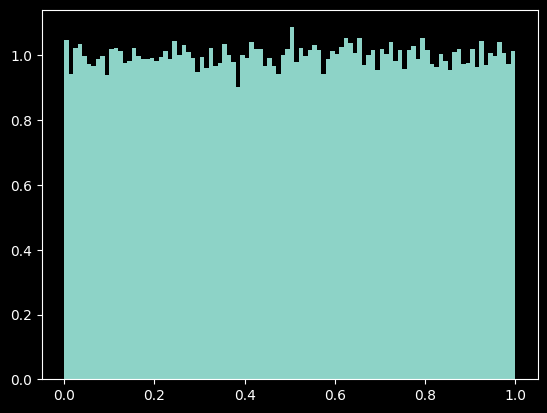

0.3313025533344365
16.6572


In [8]:
import numpy as np
from scipy import stats

# 1. Сгенерировать много чисел
rng = np.random.default_rng(seed=42)        # или свой генератор
x = rng.random(100_000)                     # или rng.uniform(0,1, N)

# 2. Быстрый взгляд
import matplotlib.pyplot as plt
plt.hist(x, bins=100, density=True)
plt.show()

# 3. Kolmogorov-Smirnov (самый популярный в задачах)
ks_stat, p_value = stats.kstest(x, 'uniform')
print(p_value)          # > 0.05 → нормально

# 4. Chi² (когда просят руками или интервалы)
bins = 20
observed, _ = np.histogram(x, bins=bins, range=(0,1))
expected = len(x) / bins
chi2 = np.sum((observed - expected)**2 / expected)
print(chi2)             # сравниваем с таблицей хи-квадрат (df = bins-1)

The choice of parameters $m$, $a$ and $c$ has a significant impact on the quality of the sequence. If the parameters are chosen unsuccessfully, it can lead to unexpected consequences:

In [49]:
def rng_bad(m=2**31, a=65539, c=0):
    rng_bad.current = (a * rng_bad.current + c) % m
    return rng_bad.current / m
rng_bad.current = 1

random = [rng_bad() for _ in range(30000)]
print("This sequence looks as random:")
random[:10]

This sequence looks as random:


[3.051897510886192e-05,
 0.00018310965970158577,
 0.0008239871822297573,
 0.003295936156064272,
 0.012359732296317816,
 0.04449496837332845,
 0.15573221957311034,
 0.533938602078706,
 0.8020416363142431,
 0.006802399177104235]

The histogram of the distribution is similar to a uniform distribution:

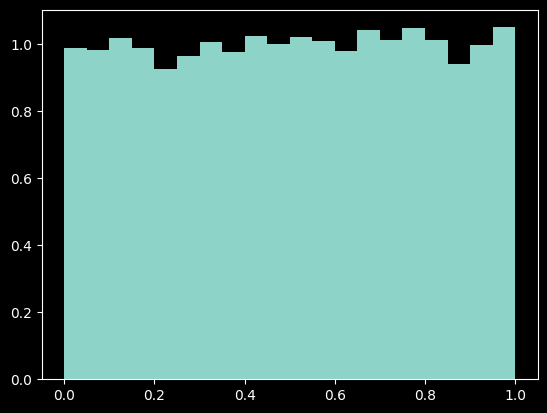

In [50]:
import matplotlib.pyplot as plt
fig = plt.figure()

plt.hist(random, 20, density=True)
plt.show()

However, the series test shows that the points are located on hyperplanes, which does not fit well with the notion of randomness:

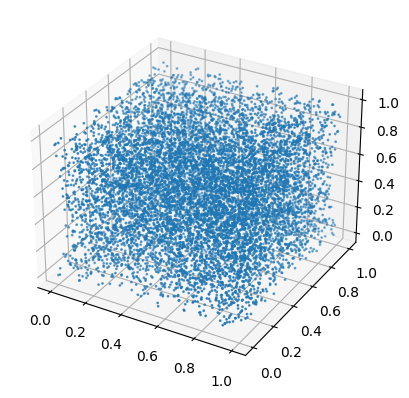

In [17]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.scatter(random[::3], random[1::3], random[2::3], s=1)
plt.show()

In [48]:
import plotly.express as px

fig = px.scatter_3d(x=random[::3], y=random[1::3], z=random[2::3], opacity=0.1)
fig.update_traces(marker_size = 2)
fig.show()

### Problem 3

Provide a statistical test to show that `rng_bad` has problems but `rng_good` does not.

In [7]:
import numpy as np
from scipy import stats

def rng_bad():
    rng_bad.state = (65539 * rng_bad.state + 0) % (2**31)
    return rng_bad.state / (2**31)

def rng_good():
    rng_good.state = (1103515245 * rng_good.state + 12345) % (2**32)
    return rng_good.state / (2**32)

def serial_test_3d(samples, bins=12):
    n = len(samples)
    n_triples = n // 3
    expected = n_triples / (bins ** 3)

    triples = np.array([samples[i:i+3] for i in range(0, n-2, 3)])
    indices = (triples * bins).astype(int)
    indices = np.clip(indices, 0, bins-1)

    observed = np.zeros((bins, bins, bins), dtype=int)
    np.add.at(observed, (indices[:,0], indices[:,1], indices[:,2]), 1)

    chi2, pvalue = stats.chisquare(observed.ravel(), [expected] * observed.size)
    return chi2, pvalue

rng_bad.state = 1
rng_good.state = 1

N = 60000
bad_samples  = [rng_bad()  for _ in range(N)]
good_samples = [rng_good() for _ in range(N)]

chi_bad,  p_bad  = serial_test_3d(bad_samples)
chi_good, p_good = serial_test_3d(good_samples)

print(f"rng_bad    χ² ={chi_bad:10.2f}   p ={p_bad:9.2e}")
print(f"rng_good   χ² ={chi_good:10.2f}   p ={p_good:9.2e}")
print(f"bad  отвергаем равномерность: {p_bad < 0.001}")
print(f"good отвергаем равномерность: {p_good < 0.001}")

rng_bad    χ² =   3167.81   p = 7.00e-88
rng_good   χ² =   1701.26   p = 6.66e-01
bad  отвергаем равномерность: True
good отвергаем равномерность: False


### Problem 4
Simulate a sample of 1000 from a discrete distribution on a set of digits $0, 1, 2, \ldots, 9$ with weights $0.12, 0.3, 0.167, 0.24, 0.31, 0.54, 0.111, 0.02, 0.001, 0.2$. Construct a histogram from the sample. Optimise the algorithm by ordering the weights.

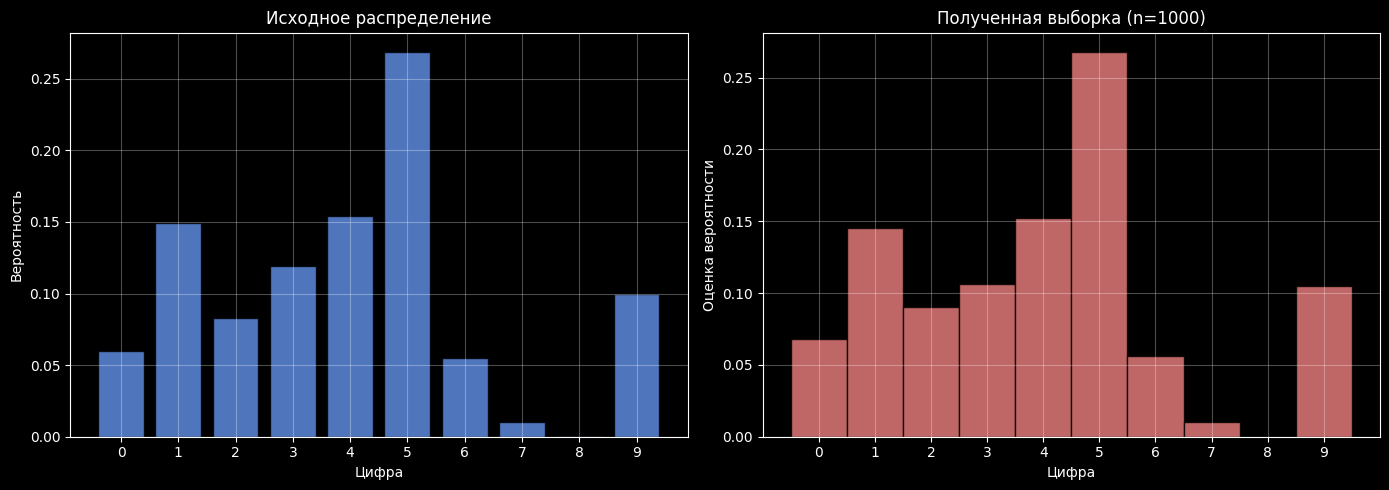

In [9]:
import numpy as np
import matplotlib.pyplot as plt

def rng():
    rng.current = (1103515245 * rng.current + 12345) % (2**32)
    return rng.current / (2**32)

rng.current = 1

digits  = np.arange(10)
weights = np.array([0.12, 0.3, 0.167, 0.24, 0.31, 0.54, 0.111, 0.02, 0.001, 0.2])
probs   = weights / weights.sum()

idx = np.argsort(-probs)
sorted_digits = digits[idx]
sorted_probs  = probs[idx]
cumsum = np.cumsum(sorted_probs)

randoms = [rng() for _ in range(1000)]
samples = np.array([sorted_digits[np.searchsorted(cumsum, r)] for r in randoms])

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.bar(digits, probs, color="cornflowerblue", edgecolor="black", alpha=0.8)
plt.title("Исходное распределение")
plt.xlabel("Цифра")
plt.ylabel("Вероятность")
plt.xticks(digits)
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(samples, bins=np.arange(-0.5, 10.5, 1), density=True,
         color="lightcoral", edgecolor="black", alpha=0.8)
plt.title("Полученная выборка (n=1000)")
plt.xlabel("Цифра")
plt.ylabel("Оценка вероятности")
plt.xticks(digits)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Problem 5
Simulate a sample of size 1000 from the distribution $\operatorname{Exp}(\lambda)$ using the Inverse transform method. Construct a sample histogram and an accurate plot of the distribution density.

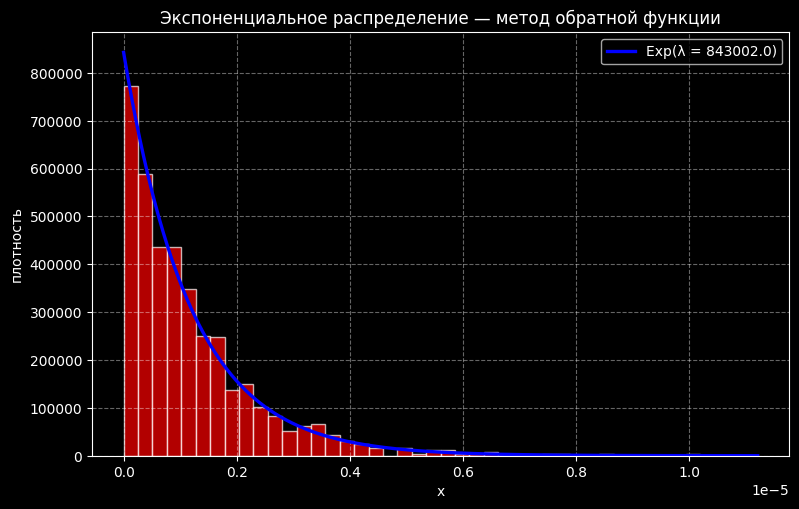

In [15]:
import numpy as np
import matplotlib.pyplot as plt

try:
    lam = float(input("λ = "))
    if lam <= 0:
        print("λ должно быть > 0")
        exit()
except:
    print("Введите корректное число")
    exit()

np.random.seed(7)

u = np.random.rand(1000)
x = -np.log(u) / lam

plt.figure(figsize=(9, 5.5))
plt.hist(x, bins=40, density=True, color='red', alpha=0.7, edgecolor='white')

t = np.linspace(0, x.max() * 1.1, 800)
plt.plot(t, lam * np.exp(-lam * t), 'b-', lw=2.4, label=f'Exp(λ = {lam})')

plt.xlabel('x')
plt.ylabel('плотность')
plt.title('Экспоненциальное распределение — метод обратной функции')
plt.legend()
plt.grid(ls='--', alpha=0.4)
plt.show()

### Problem 6
Justify (orally) that the accept-reject method really samples from the required distribution. Simulate $1000$ points from the distribution with density $$e^xcos^2x \cdot \mathbb{I}_{[-\frac\pi2, \frac\pi2]}$$. Plot the sampled histogram on the sample and compare it with the plot of the exact density function.

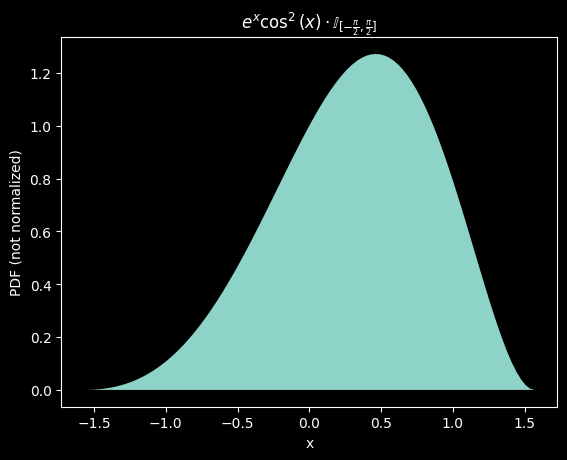

In [18]:
fig = plt.figure()

x = np.linspace(-np.pi/2, np.pi/2, 100)
density = np.exp(x) * np.cos(x) ** 2
plt.fill_between(x, 0, density)
plt.ylabel('PDF (not normalized)')
plt.xlabel('x')
plt.title(r'$e^x \cos^2(x) \cdot \mathbb{I}_{[-\frac{\pi}{2}, \frac{\pi}{2}]}$')

plt.show()

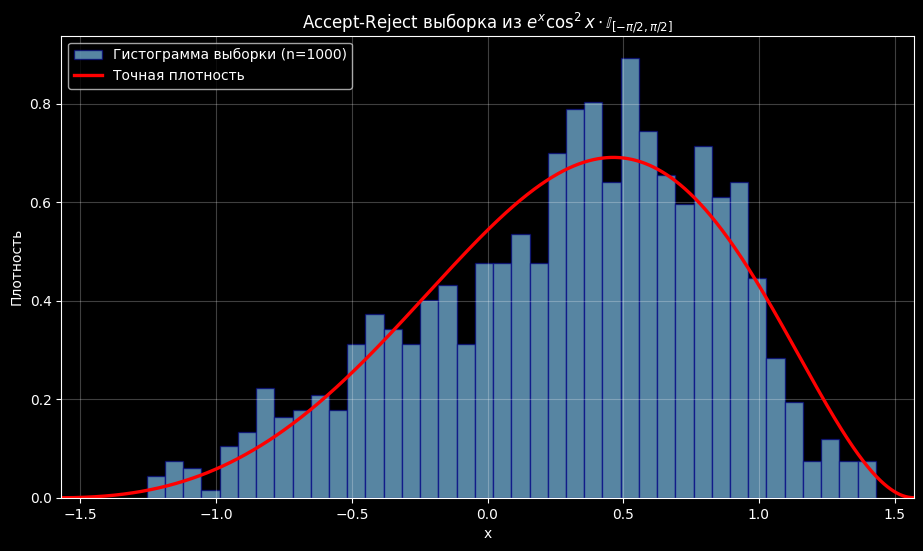

Верхняя граница M ≈ 1.27189
Ожидаемая эффективность принятия ≈ 2.4700


In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

a, b = -np.pi / 2, np.pi / 2
target = lambda x: np.exp(x) * (np.cos(x) ** 2)

res = minimize_scalar(lambda x: -target(x), bounds=(a, b), method='bounded')
M = target(res.x)

norm = (2 * np.exp(np.pi) - 2) / (5 * np.exp(np.pi / 2))
density = lambda x: target(x) / norm

def rejection_sampling(n, seed=42):
    np.random.seed(seed)
    samples = []
    while len(samples) < n:
        x = np.random.uniform(a, b)
        y = np.random.uniform(0, M)
        if y <= target(x):
            samples.append(x)
    return np.array(samples)


samples = rejection_sampling(1000)

plt.figure(figsize=(11, 6))

plt.hist(samples, bins=40, density=True, alpha=0.65, color='lightskyblue',
         edgecolor='navy', label='Гистограмма выборки (n=1000)')

x_plot = np.linspace(a, b, 1000)
plt.plot(x_plot, density(x_plot), 'r-', lw=2.4, label='Точная плотность')

plt.xlabel('x')
plt.ylabel('Плотность')
plt.title(r'Accept-Reject выборка из $e^x \cos^2 x \cdot \mathbb{I}_{[-\pi/2, \pi/2]}$')
plt.legend()
plt.grid(True, alpha=0.25)
plt.xlim(a, b)
plt.show()

print(f"Верхняя граница M ≈ {M:.5f}")
print(f"Ожидаемая эффективность принятия ≈ {1/M * (b-a):.4f}")

### Problem 7
Model and depict a sample of 500 points uniformly distributed within a given triangle without using a selection method.

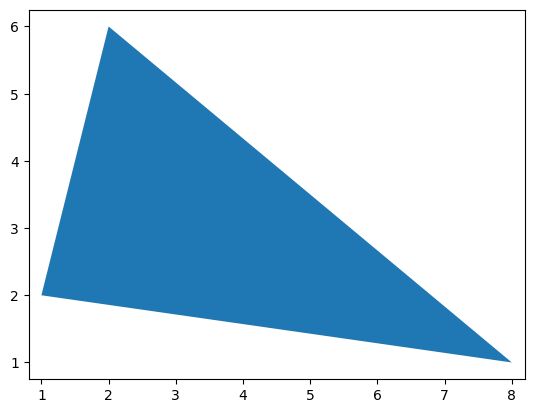

In [54]:
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection

fig = plt.figure()

polygon = Polygon(xy=np.array([[1, 2], [2, 6], [8, 1]]), closed=True)
plt.gca().add_collection(PatchCollection([polygon]))
plt.axis('equal')
plt.show()

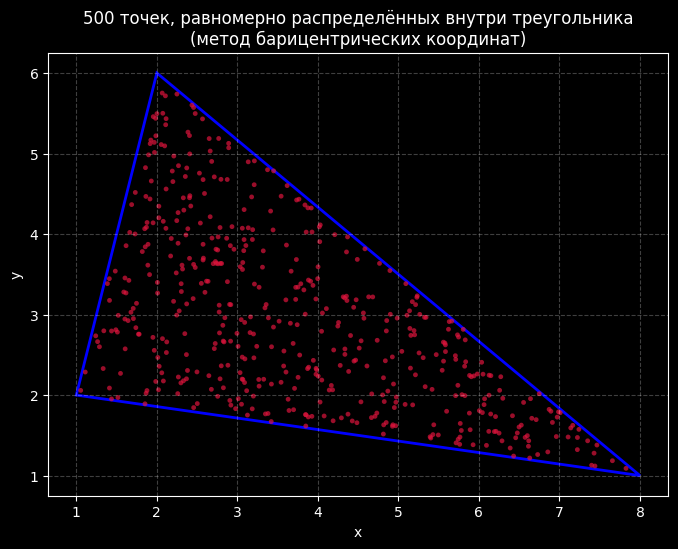

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection

A = np.array([1, 2])
B = np.array([2, 6])
C = np.array([8, 1])

n = 500
np.random.seed(42)

r1 = np.random.exponential(size=n)
r2 = np.random.exponential(size=n)
r3 = np.random.exponential(size=n)

s = r1 + r2 + r3
alpha = r1 / s
beta  = r2 / s
gamma = r3 / s

points = alpha[:, np.newaxis] * A + beta[:, np.newaxis] * B + gamma[:, np.newaxis] * C

fig, ax = plt.subplots(figsize=(8, 7))

triangle = Polygon([A, B, C], closed=True, fill=None, edgecolor='blue', linewidth=2)
ax.add_patch(triangle)

ax.scatter(points[:,0], points[:,1], s=12, color='crimson', alpha=0.7, edgecolor='none')

ax.set_aspect('equal')
ax.set_title("500 точек, равномерно распределённых внутри треугольника\n(метод барицентрических координат)")
ax.grid(True, alpha=0.25, linestyle='--')
ax.set_xlabel('x')
ax.set_ylabel('y')

plt.show()

### Problem 8
Model without using the selection method a sample of $500$ points uniformly distributed inside the unit circle. Picture the obtained points. Do they really fill the circle uniformly?

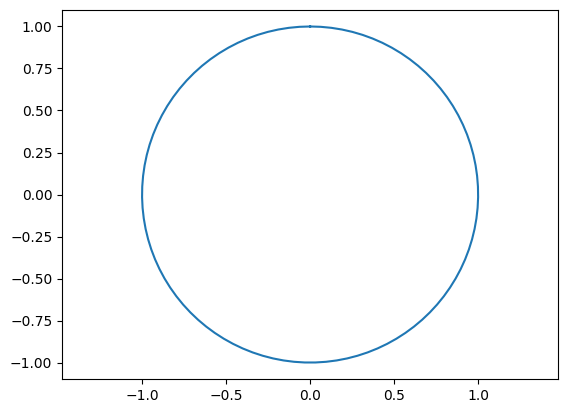

In [56]:
fig = plt.figure()

t = np.linspace(0, 2*np.pi, 100)
plt.plot(np.sin(t), np.cos(t))
plt.axis('equal')
plt.show()

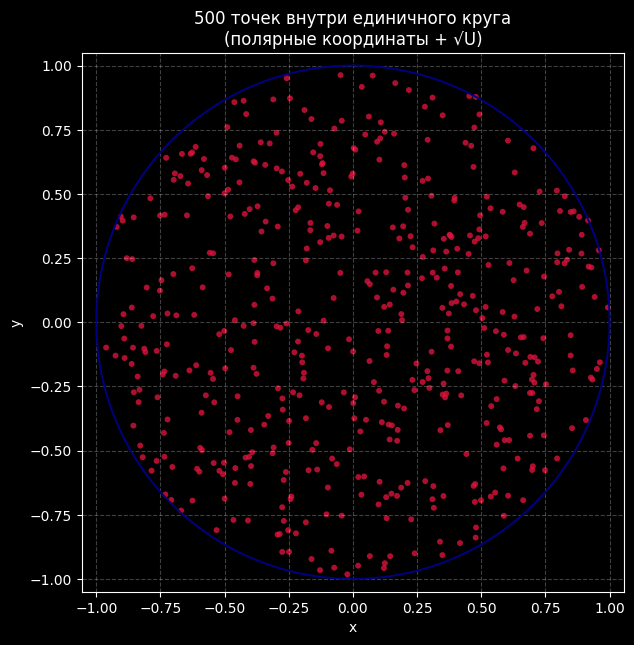

In [22]:
import numpy as np
import matplotlib.pyplot as plt

n = 500
np.random.seed(42)

theta = np.random.uniform(0, 2*np.pi, n)

r = np.sqrt(np.random.uniform(0, 1, n))

x = r * np.cos(theta)
y = r * np.sin(theta)

plt.figure(figsize=(7, 7))
plt.plot(np.cos(np.linspace(0, 2*np.pi, 200)),
         np.sin(np.linspace(0, 2*np.pi, 200)),
         color='navy', lw=1.4)

plt.scatter(x, y, s=18, color='crimson', alpha=0.8, edgecolor='none')

plt.axis('equal')
plt.grid(alpha=0.25, ls='--')
plt.title("500 точек внутри единичного круга\n(полярные координаты + √U)")
plt.xlabel("x")
plt.ylabel("y")
plt.xlim(-1.05, 1.05)
plt.ylim(-1.05, 1.05)
plt.show()

# Random normal generator

### Problem 9
Prove (orally) that the following algorithm (**Box-Muller algorithm**, https://en.wikipedia.org/wiki/Box%E2%80%93Muller_transform) generates a sample of independent $\mathcal{N}(0,1)$ random variables. Modify the method to exclude calls of trigonometric functions `np.sin` and `np.cos`. Using the modified method, simulate a sample size of $1000$ from a $2D$ Gaussian distribution with mean $\mu$ and covariance matrix $\Sigma$, where
$$\mu = \begin{pmatrix} 4 \\ 7 \end{pmatrix}^T, \quad \Sigma = \begin{pmatrix} 20 & -4 \\ -4 & 40 \end{pmatrix}.$$
Construct a 2D histogram of the resulting distribution. Compare the sample mean and covariance matrix with the exact values.

In [58]:
import seaborn as sns

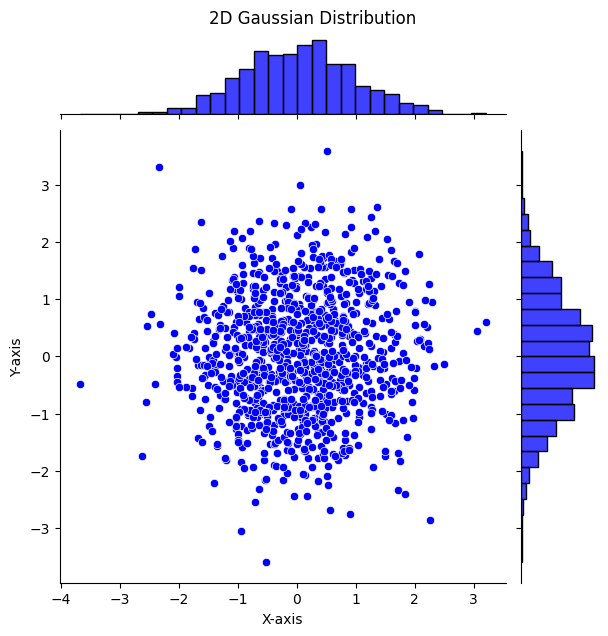

In [59]:
n = 1000
u1, u2 = np.random.rand(2, n)
r = np.sqrt(-2 * np.log(u1))
theta = 2 * np.pi * u2
x = r * np.cos(theta)
y = r * np.sin(theta)


joint_plot = sns.jointplot(x=x, y=y, color="blue")
joint_plot.set_axis_labels('X-axis', 'Y-axis')
plt.suptitle('2D Gaussian Distribution', y=1.02)
plt.show()

Точное среднее:
[4. 7.]

Выборочное среднее:
[4.2548 7.1568]

Точная ковариационная матрица:
[[20 -4]
 [-4 40]]

Выборочная ковариационная матрица:
[[20.6028 -4.05  ]
 [-4.05   37.0434]]


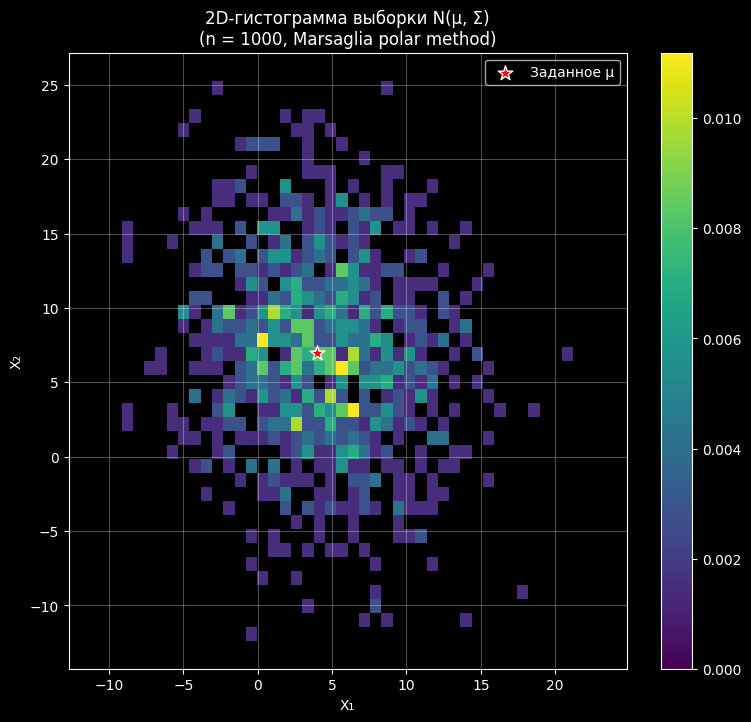

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def marsaglia_polar(n):
    samples = []
    np.random.seed(42)

    while len(samples) < n:
        u = np.random.uniform(-1, 1, (1000, 2))
        s = np.sum(u**2, axis=1)
        mask = (s < 1) & (s > 0)

        multiplier = np.sqrt(-2 * np.log(s[mask]) / s[mask])
        z = u[mask] * multiplier[:, np.newaxis]

        samples.append(z)

    return np.vstack(samples)[:n].T


mu = np.array([4.0, 7.0])
Sigma = np.array([[20, -4],
                  [-4, 40]])

L = np.linalg.cholesky(Sigma)

n = 1000
Z = marsaglia_polar(n)
X = L @ Z + mu[:, np.newaxis]

mean_sample = np.mean(X, axis=1)
cov_sample  = np.cov(X)

print("Точное среднее:")
print(mu)
print("\nВыборочное среднее:")
print(np.round(mean_sample, 4))

print("\nТочная ковариационная матрица:")
print(Sigma)
print("\nВыборочная ковариационная матрица:")
print(np.round(cov_sample, 4))

plt.figure(figsize=(9, 8))
sns.histplot(x=X[0], y=X[1], bins=40, cmap="viridis", cbar=True,
             stat="density")
plt.scatter(mu[0], mu[1], color="red", s=120, marker="*",
            edgecolor="white", zorder=10, label="Заданное μ")

plt.title("2D-гистограмма выборки N(μ, Σ)\n(n = 1000, Marsaglia polar method)")
plt.xlabel("X₁")
plt.ylabel("X₂")
plt.grid(alpha=0.3)
plt.axis("equal")
plt.legend()
plt.show()

### Problem 10*

Implement a method of generating a random partition of an n-element set into subsets. Use it to estimate the expected number of subsets in a random partition of a set of 100 elements.

Hint 1: Ширяев, Вероятность, т1, задача 2 к параграфу 1.

Hint 2: http://djalil.chafai.net/blog/2012/05/03/generating-uniform-random-partitions/

In [61]:
# Your code here

# Basic distributions
- **Uniform distribution $\operatorname{U}[a, b]$**:
$$p(x) = \frac{1}{b-a}\cdot\mathbb{I}_{x\in[a, b]}$$

- **Exponential distribution $\operatorname{Exp}(\lambda)$**:
$$p(x) = \lambda e^{-\lambda x}\cdot\mathbb{I}_{x\geqslant0}$$

- **Normal distribution $\mathcal{N}(\mu, \sigma^2)$**:
$$p(x) = \frac{1}{\sqrt{2\pi}\sigma}e^{-\frac{(x-\mu)^2}{2\sigma^2}}$$

- **Gamma distribution $\operatorname{Gamma}(\alpha, \lambda)$**:
$$p(x) = \frac{\lambda^\alpha}{\Gamma(\alpha)}x^{\alpha-1}e^{-\lambda x}\cdot\mathbb{I}_{x\geqslant0}$$

- **Beta distribution $\operatorname{Beta}(\alpha, \beta)$**:
$$p(x) = \frac{\Gamma(\alpha+\beta)}{\Gamma(\alpha)\Gamma(\beta)}x^{\alpha-1}(1-x)^{\beta-1}\cdot\mathbb{I}_{x\in[0, 1]}$$

- **$\chi^2$ distribution with $k$ degrees of freedom $\chi^2(k)$**:
$$p(x) = \frac{1}{2^{k/2}\Gamma(k/2)}x^{k/2-1}e^{-x/2}\cdot\mathbb{I}_{x\geqslant0}$$



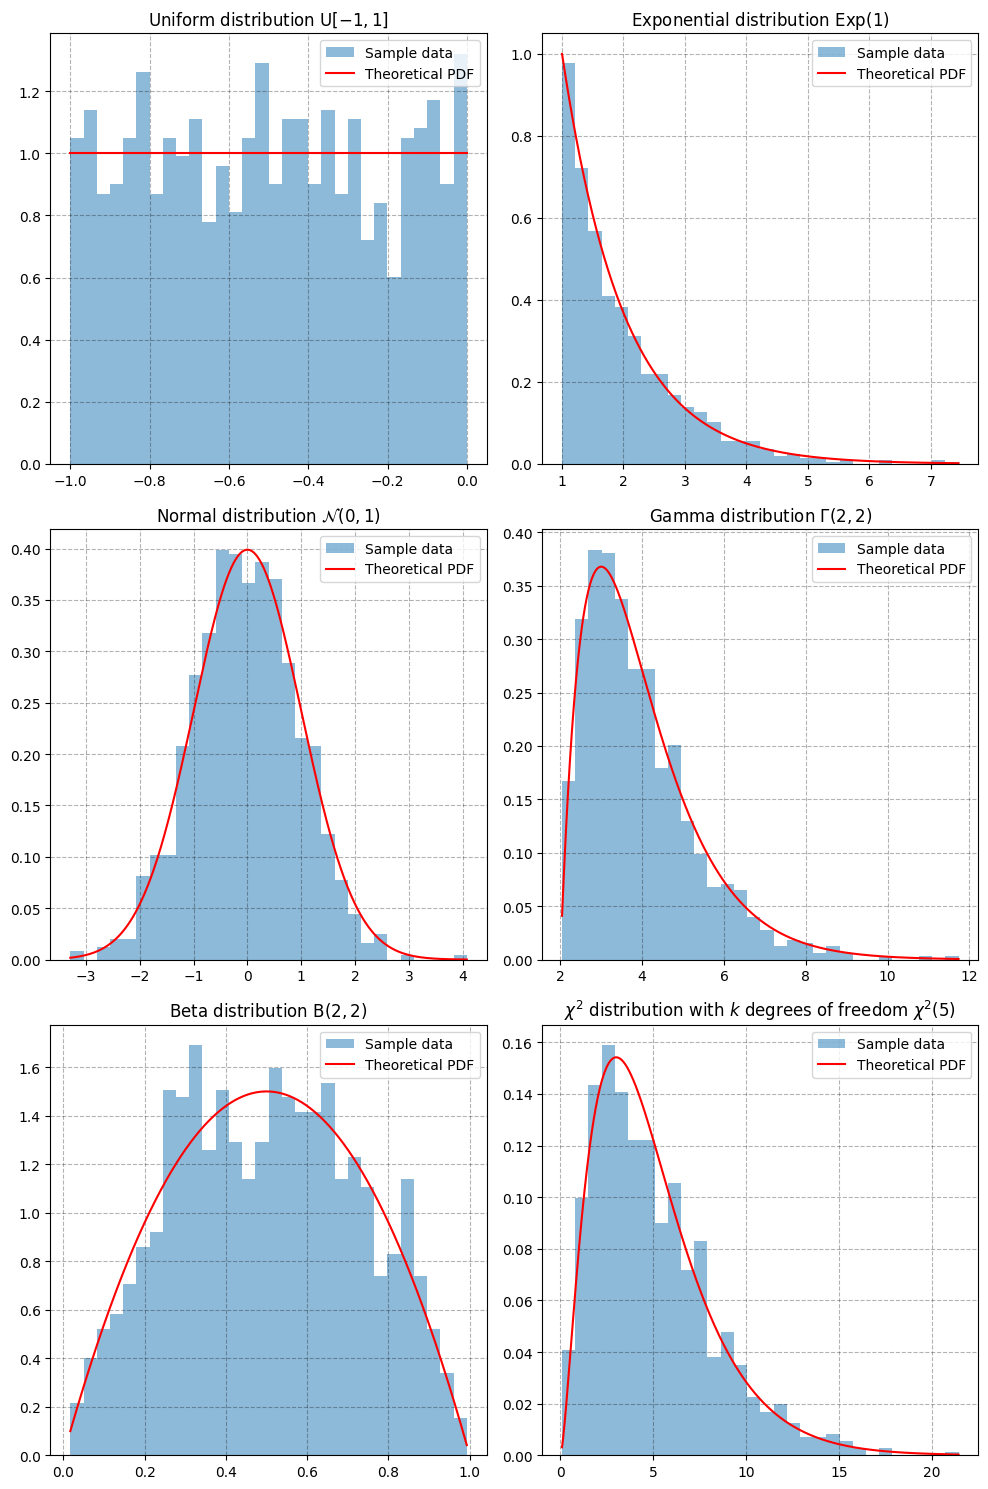

In [69]:
# Define distributions and their parameters
distributions = [
    ("Uniform distribution $\\operatorname{U}[-1, 1]$", stats.uniform, (-1, 1)),
    ("Exponential distribution $\\operatorname{Exp}(1)$", stats.expon, (1,)),
    ("Normal distribution $\\mathcal{N}(0, 1)$", stats.norm, (0, 1)),
    ("Gamma distribution $\\Gamma(2, 2)$", stats.gamma, (2, 2)),
    ("Beta distribution $\\operatorname{B}(2, 2)$", stats.beta, (2, 2)),
    ("$\\chi^2$ distribution with $k$ degrees of freedom $\\chi^2(5)$", stats.chi2, (5,))
]

# Setup the figure and axes for a 2x3 subplot
fig, axs = plt.subplots(3, 2, figsize=(10, 15))  # Adjust figsize according to your needs
axs = axs.flatten()  # Flatten the array to easily iterate over it

for ax, (name, dist, params) in zip(axs, distributions):
    # Generate sample data
    data = dist.rvs(*params, size=1000)
    # Generate points for PDF
    x = np.linspace(min(data), max(data), 1000)
    pdf = dist.pdf(x, *params)
    
    # Plot histogram of sample data
    ax.hist(data, bins=30, density=True, alpha=0.5, label='Sample data')
    # Plot theoretical PDF
    ax.plot(x, pdf, 'r-', label='Theoretical PDF')
    ax.set_title(name)
    ax.legend()
    ax.grid(linestyle='--', color='black', alpha=0.3)

plt.tight_layout()  # Adjust subplots to fit in the figure area
plt.show()
